# <span style = 'color:#9500ff'>Decision Tree Regressor</span>
> <span style = 'color:white'>BostonHousing.csv</span>

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split, GridSearchCV

In [4]:
df = pd.read_csv('BostonHousing.csv')
df.sample(10)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
17,0.78420,0.0,8.14,0,0.538,5.990,81.7,4.2579,4,307,21.0,386.75,14.67,17.5
403,24.80170,0.0,18.10,0,0.693,5.349,96.0,1.7028,24,666,20.2,396.90,19.77,8.3
161,1.46336,0.0,19.58,0,0.605,7.489,90.8,1.9709,5,403,14.7,374.43,1.73,50.0
32,1.38799,0.0,8.14,0,0.538,5.950,82.0,3.9900,4,307,21.0,232.60,27.71,13.2
40,0.03359,75.0,2.95,0,0.428,7.024,15.8,5.4011,3,252,18.3,395.62,1.98,34.9
347,0.01870,85.0,4.15,0,0.429,6.516,27.7,8.5353,4,351,17.9,392.43,6.36,23.1
355,0.10659,80.0,1.91,0,0.413,5.936,19.5,10.5857,4,334,22.0,376.04,5.57,20.6
376,15.28800,0.0,18.10,0,0.671,6.649,93.3,1.3449,24,666,20.2,363.02,23.24,13.9
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [14]:
# Features and target
x = df.iloc[:, 0:-1]
y = df.iloc[:, -1]

# split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

### Hyperparameter tuning

In [11]:
param_grid = {
    "criterion": ["squared_error", "friedman_mse", "absolute_error"],
    "splitter": ["best", "random"],
    "max_depth": [3,5,7,10,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4],
    "max_features": [None, "sqrt", "log2"],
    "max_leaf_nodes": [None,10,20,30,50]
}

grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv = 5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(x_train, y_train)

# best hyperpartameters
print("Best Hyperparameters:")
print(grid.best_params_)
# best CV score
print("\nBest Cross Validation Score:")
print(round(grid.best_score_,4))

Best Hyperparameters:
{'criterion': 'absolute_error', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'splitter': 'random'}

Best Cross Validation Score:
0.7788


### Best Model

In [13]:
dt = grid.best_estimator_
dt

DecisionTreeRegressor(criterion='absolute_error', min_samples_leaf=2,
                      random_state=42, splitter='random')

In [16]:
# model train
dt.fit(x_train, y_train)
y_Pred = dt.predict(x_test)
print('R2 score: ',r2_score(y_test, y_Pred))

R2 score:  0.7842733820915537


### Feature Importance

In [18]:
importance_df = pd.DataFrame({
    'Feature':x.columns,
    'Importance':dt.feature_importances_
})

importance_df

,Feature,Importance
0,crim,0.022756
1,zn,0.004013
2,indus,0.013590
3,chas,0.003238
4,nox,0.026769
5,rm,0.420513
6,age,0.149352
7,dis,0.025903
8,rad,0.040998
9,tax,0.010215


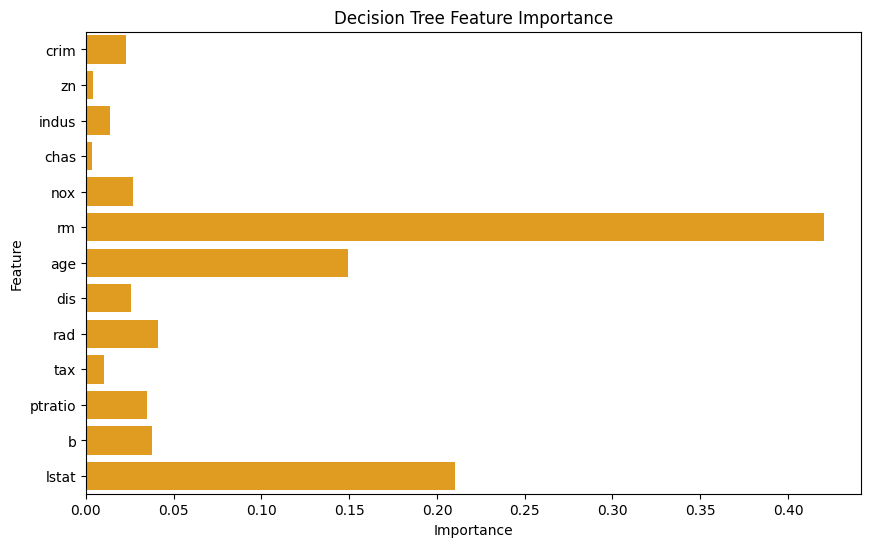

In [21]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature",
    color='Orange'
)

plt.title("Decision Tree Feature Importance")
plt.show()

### Dimensionality Reduction

In [27]:
# keeping the features of importance > 0.02
selected_features = importance_df[importance_df['Importance'] > 0.02]['Feature'].to_list()
selected_features

['crim', 'nox', 'rm', 'age', 'dis', 'rad', 'ptratio', 'b', 'lstat']

In [30]:
x_reduced = df[selected_features]
x_reduced.columns

Index(['crim', 'nox', 'rm', 'age', 'dis', 'rad', 'ptratio', 'b', 'lstat'], dtype='object')

### Model train on Reduded dataset

In [32]:
# data split
x_trainr, x_testr, y_trainr, y_testr = train_test_split(x_reduced, y, test_size=0.2, random_state=42)

In [33]:
best_model_reduced = DecisionTreeRegressor(random_state=42, **grid.best_params_)
best_model_reduced.fit(x_trainr, y_trainr)

DecisionTreeRegressor(criterion='absolute_error', min_samples_leaf=2,
                      random_state=42, splitter='random')

In [34]:
y_predr = best_model_reduced.predict(x_testr)

print("Reduced Dataset R2 Score:",
      round(r2_score(y_testr, y_predr),4))

Reduced Dataset R2 Score: 0.7829


In [ ]:
print("\nEnter values for prediction:\n")

user_data = []

for feature in selected_features:
    value = float(input(f"{feature}: "))
    user_data.append(value)

user_df = pd.DataFrame(
    [user_data],
    columns=selected_features
)

prediction = best_model_reduced.predict(user_df)

print("Predicted House Price :", round(prediction[0],2))


Enter values for prediction:


Predicted House Price : 22.35


> <span style = 'color:orange'>**median value of owner-occupied homes in $1000s.**</span>